### Jeremy Marino

### DS4420

### Final Project 

### College Baseball Seasonal Pitching/Hitting Analysis - Time Series

## Time Series Model Goals

### Steps to implement
- Load and clean the data
- Choose batting and pitching metrics
- Standardize the stats if needed
- Encode teams, conferences, and seasons
- Fit Time Series model
- Understand relation between pitching and batting. Predict furture relationships

## Hypothesis

The reason I believe this project to be so interest is because of the relationships between the different divisions of play. I am of the opinion that the trends may differ by division because of disparity of talent between levels. Because of this, I believe the higher the division, the closer the teams and conferences will follow professional in terms of pitching and battling (i.e. higher strikeout rates and higher home run/SLG rates).

## Load/Clean Data

In [587]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.api import AutoReg
from statsmodels.tsa.stattools import adfuller

from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

In [6]:
div1_df = pd.read_json(r'C:\Users\Jerem\Documents\NU SPRING 2026\DS4420\FINAL PROJECT\DS4420-BiggsMarino-Final-Project\Data\div1\2012.json').T
div1_df.shape

(292, 46)

In [8]:
div1_df.head(10)

,team,league,W,L,T,WPCT,G,BB (Batting),AB,H,...,SLG,SBPG,SO,BB (Pitching),K/BB,K/9,3B,3BPG,WHIP,BBPG (Pitching)
Utah Valley (GWC),Utah Valley,GWC,47,12,0,0.797,59,271,2031,711,...,0.523,0.92,347,169,2.05,6.3,30,0.51,1.47,3.08
Stony Brook (America East),Stony Brook,America East,52,15,0,0.776,67,243,2245,743,...,0.478,1.37,394,176,2.24,6.2,36,0.54,1.18,2.78
Purdue (Big Ten),Purdue,Big Ten,45,14,0,0.763,59,187,2107,665,...,0.431,1.03,364,128,2.84,6.2,17,0.29,1.21,2.18
UCLA (Pac-12),UCLA,Pac-12,48,16,0,0.75,64,228,2135,650,...,0.393,0.94,436,238,1.83,6.9,16,0.25,1.3,3.76
Florida St. (ACC),Florida St.,ACC,50,17,0,0.746,67,386,2230,627,...,0.414,0.94,498,228,2.18,7.5,10,0.15,1.33,3.43
Baylor (Big 12),Baylor,Big 12,49,17,0,0.742,66,296,2183,675,...,0.442,1.45,448,185,2.42,6.9,17,0.26,1.2,2.86
North Carolina (ACC),North Carolina,ACC,46,16,0,0.742,62,304,2127,587,...,0.384,1.15,530,205,2.59,8.5,25,0.4,1.25,3.27
Arizona (Pac-12),Arizona,Pac-12,48,17,0,0.738,65,234,2296,756,...,0.447,1.31,443,168,2.64,6.8,35,0.54,1.27,2.58
Army West Point (Patriot),Army West Point,Patriot,41,15,0,0.732,56,197,1748,502,...,0.362,1.95,346,148,2.34,6.6,7,0.13,1.2,2.81
UCF (CUSA),UCF,CUSA,45,17,0,0.726,62,277,2128,617,...,0.418,1.45,484,238,2.03,7.7,12,0.19,1.4,3.79


In [270]:
div1_df['IP']

Utah Valley (GWC)             494.0
Stony Brook (America East)    570.7
Purdue (Big Ten)              527.7
UCLA (Pac-12)                 569.0
Florida St. (ACC)             598.3
                              ...  
Alabama A&M (SWAC)            412.3
Florida A&M (MEAC)            419.3
New York Tech (GWC)           408.0
Coppin St. (MEAC)             417.3
division                          1
Name: IP, Length: 292, dtype: object

In [264]:
div2_df = pd.read_json(r'C:\Users\Jerem\Documents\NU SPRING 2026\DS4420\FINAL PROJECT\DS4420-BiggsMarino-Final-Project\Data\div2\2012.json').T
div2_df.columns

Index(['team', 'league', 'W', 'L', 'T', 'WPCT', 'G', 'BB (Batting)', 'AB', 'H',
       'BA', 'DP', 'DPPG', '2B', '2BPG', 'IP', 'R (Pitching)', 'ER', 'ERA',
       'PO', 'A', 'E', 'FPCT', 'HBP', 'HA', 'HAPG', 'HR', 'HRPG',
       'R (Batting)', 'SB', 'CS', 'SF', 'RPG', 'TB', 'SLG', 'SBPG', 'SO',
       'K/9', '3B', '3BPG', 'BB (Pitching)', 'BBPG (Pitching)'],
      dtype='object')

Mateo has pretty well structured data here for all 3 levels of college baseball, most of the wrangling will involve aggragting seasonal data into groups by conference, division, etc.

## Batting/Pitching Metrics

These are our initial metrics we will pass in as features for our model. They are not necessarily the best and our subject to change, however they provide a good baseline for our model.

Here is the documentation for features in this dataset: https://collegebaseballstatspackage.readthedocs.io/en/latest/season_stats.html 

### Batting Metrics

- BA (Batting Average)
- OBP (On-Base Percentage)
- SLG (Slugging Percentage)
- HRPG (Home-Run Percentage)
- RPG (Runs Per Game)

### Pitching Metrics

- ERA (Earned Run Average)
- WHIP (Walks and Hits Per Inning Pitched)
- K/9 (Strikeouts Per 9 Innings Pitched)
- K/BB (Strikeouts / Walk Ratio)

In [252]:
# consts

DIV_1_CONFERENCES = [
    'America_East', 'Big_Ten', 'Pac-12', 'ACC', 'Big_12',
    'Patriot', 'CUSA', 'SEC', 'WCC', 'MAC', 'MEAC', 'Big_South',
    'Atlantic_10', 'SoCon', 'MVC', 'SWAC', 'Summit_League',
    'The_American', 'Southland', 'Mountain_West', 'ASUN', 'Big_West',
    'Ivy_League', 'Horizon', 'CAA', 'OVC', 'Sun_Belt', 'NEC', 'WAC',
    'MAAC'
]

DIV_2_CONFERENCES = [
    'CACC', 'CCAA', 'Conference_Carolinas', 'East_Coast',
    'GAC', 'GLIAC', 'GLVC', 'GNAC', 'Great_Midwest',
    'Gulf_South', 'Heartland', 'Lone_Star', 'MIAA',
    'Mountain_East', 'NE-10', 'Northern_Sun', 'Peach_Belt',
    'PSAC', 'RMAC', 'South_Atlantic', 'SIAC',
    'Sunshine_State'
]

DIV_3_CONFERENCES = [
    'Allegheny_Mountain', 'American_Rivers', 'American_Southwest',
    'Atlantic_East', 'Centennial', 'Coast_to_Coast', 'CCIW',
    'Colonial_States', 'Commonwealth_Coast', 'Collegiate_South',
    'CUNY', 'Empire_8', 'Great_Northeast', 'Heartland_Collegiate',
    'Landmark', 'Liberty_League', 'Little_East', 'MASCAC',
    'Michigan_Intercollegiate', 'Middle_Atlantic', 'Midwest',
    'MIAC', 'NECC', 'NESCAC', 'NEWMAC',
    'NJAC', 'North_Atlantic', 'NACC', 'North_Coast',
    'Northwest', 'OAC', 'ODAC', 'Presidents',
    'SAA', 'SCIAC', 'Skyline', 'SLIAC',
    'SUNYAC', 'United_East', 'UAA', 'Upper_Midwest',
    'USA_South', 'WIAC'
]

CONFERENCE_DICT = {
    1: DIV_1_CONFERENCES,
    2: DIV_2_CONFERENCES,
    3: DIV_3_CONFERENCES,
}

BAT_METRICS = [
    'BA',
    'OBP',
    'SLG',
    'HRPG',
    'RPG',
]

PITCH_METRICS = [
    'ERA',
    'WHIP',
    'K/9',
    'K/BB'
]

Before we move forward with our data, it's important to note that division 2 and 3 stats post-2012 are missing OBP, WHIP, and K/BB as seen below. Lets aggregate those features since we have the values to do so.

In [382]:
div3_df = pd.read_json(r'C:\Users\Jerem\Documents\NU SPRING 2026\DS4420\FINAL PROJECT\DS4420-BiggsMarino-Final-Project\Data\div3\2012.json').T
div3_df.columns

Index(['team', 'league', 'W', 'L', 'T', 'WPCT', 'G', 'BB (Batting)', 'AB', 'H',
       'BA', 'DP', 'DPPG', '2B', '2BPG', 'IP', 'R (Pitching)', 'ER', 'ERA',
       'PO', 'A', 'E', 'FPCT', 'HBP', 'HA', 'HAPG', 'HR', 'HRPG',
       'R (Batting)', 'SB', 'CS', 'SF', 'RPG', 'TB', 'SLG', 'SBPG', 'SO',
       'K/9', '3B', '3BPG', 'BB (Pitching)', 'BBPG (Pitching)'],
      dtype='object')

In [384]:
def aggregate_metrics(df):
    """
    Used for div2 and 3 which don't have OBP, WHIP, and K/BB Aggregated
    
    Parameters:
        df:   DataFrame of metrics

    Returns:
        df:   DataFrame with aggregated metrics:
            OBP  = (H + BB + HBP) / (AB + BB + HBP + SF)
            WHIP = (BB_pitching + HA) / IP
            K/BB = SO / BB_pitching  (strikeouts / walks allowed)
    """
    df = df.copy()

    df['OBP'] = (
        (df['H'] + df['BB (Batting)'] + df['HBP']) /
        (df['AB'] + df['BB (Batting)'] + df['HBP'] + df['SF'])
    )

    df['WHIP'] = (df['BB (Pitching)'] + df['HA']) / df['IP']

    df['K/BB'] = df['SO'] / df['BB (Pitching)'].replace(0, np.nan)

    return df

Now we can average each division's target metrics by conference. This will allow use to get the stats we need at a conference by conference and division by division basis.

In [389]:
# returns dict with historic conference data
def get_historic_division_data(div=1):
    """
    Creates a df for all the average stats by year for each conference in a given division
    
    Parameters:
        div:             What division should be parsed

    Returns:
        division_dict:   Each conference's average target metrics by year in a given division 
    """
    division_dict = {}
    # data is from 2012-2025
    for year in range(2012, 2026):
        path = f'C:/Users/Jerem/Documents/NU SPRING 2026/DS4420/FINAL PROJECT/DS4420-BiggsMarino-Final-Project/Data/div{div}/{year}.json'
        df = pd.read_json(path).T
        if div != 1:
            df = aggregate_metrics(df)
        year_confs = [conf.replace(' ', '_') for conf in df['league'].unique()[:-1]] 
        for conf, conf_ in zip(df['league'].unique()[:-1], year_confs):
            division_dict[f'{conf_}_{year}'] = {
                'BA': round(float(df[df['league'] == conf]['BA'].mean()), 3),
                'OBP': round(float(df[df['league'] == conf]['OBP'].mean()), 3),
                'SLG': round(float(df[df['league'] == conf]['SLG'].mean()), 3),
                'HRPG': round(float(df[df['league'] == conf]['HRPG'].mean()), 3),
                'RPG': round(float(df[df['league'] == conf]['RPG'].mean()), 3),
                'ERA': round(float(df[df['league'] == conf]['ERA'].mean()), 3),
                'WHIP': round(float(df[df['league'] == conf]['WHIP'].mean()), 3),
                'K/9': round(float(df[df['league'] == conf]['K/9'].mean()), 3),
                'K/BB': round(float(df[df['league'] == conf]['K/BB'].mean()), 3)
            }
    return division_dict

In [254]:
# filter to only conferences present in all 14 seasons
def get_full_conferences(conf_dict, div=1):
    years = list(range(2012, 2026))
    return [
        conf for conf in CONFERENCE_DICT[div]
        if all(f'{conf}_{year}' in conf_dict for year in years)
    ]

# prints graph of conference's current trend, all_conf argument prints all conferences for the metric
# use conference notation above for conf_ argument 
def get_conf_trend(conf_dict, metric, conf_=None, all_conf=False, div=1, visualizations=False):
    years = list(range(2012, 2026))
    full_conferences = get_full_conferences(conf_dict, div=div)
    if visualizations:
        plt.figure(figsize=(12, 6))

    if all_conf:
        # collect all conference values per year for division average
        year_values = {year: [] for year in years}
        for conf in sorted(full_conferences):
            values = []
            valid_years = []
            for year in years:
                key = f'{conf}_{year}'
                valid_years.append(year)
                values.append(conf_dict[key][metric])
                year_values[year].append(conf_dict[key][metric])
            if visualizations:
                plt.plot(valid_years, values, marker='o', alpha=0.4, label=conf)

        # division-wide average line
        avg_years = [y for y in years if year_values[y]]
        avg_values = [np.mean(year_values[y]) for y in avg_years]
        if visualizations:
            plt.plot(avg_years, avg_values, color='black', linewidth=2.5,
                     linestyle='--', marker='s', label='Division Avg')
            plt.title(f'{metric} Average by Conference since 2012')
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)

        years_return = avg_years
        values_return = avg_values
    else:
        values = []
        valid_years = []
        for year in years:
            key = f'{conf_}_{year}'
            if key in conf_dict:
                valid_years.append(year)
                values.append(conf_dict[key][metric])
        if visualizations:
            plt.plot(valid_years, values, marker='o', alpha=0.6)
            plt.title(f'{metric} Average in {conf_} since 2012')

        years_return = valid_years
        values_return = values
    if visualizations:
        plt.xlabel('Year')
        plt.ylabel(f'{metric} Average')
        plt.xticks(years, rotation=45)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
    return years_return, values_return

Our ACF and PACF function will plot for given data, allowing us to understand what model is appropriate along with what lag to use.

In [547]:
def get_acf_pacf(metric, metric_df, div=1):
    """
    Draw ACF and PACF graphs for metrics
    
    Parameters:
        metric:      Stat that is to be modeled (BA, OBP, etc)
        metric_df:   DataFrame of metric (pre-filtered)
        div:         What division should be parsed
    """
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    plot_acf(metric_df[f'avg_{metric}_{div}'], ax=ax[0], title=f'Division {div} {metric} ACF Plot')
    ax[0].grid(True, alpha=0.3)

    plot_pacf(metric_df[f'avg_{metric}_{div}'], ax=ax[1], title=f'Division {div} {metric} PACF Plot')
    ax[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{metric} ACF and PACF Plots.png', bbox_inches='tight', dpi=300)
    plt.show()

In [288]:
historic_division_stats = {} 
for div in range (1, 4):
    historic_division_stats[div] = get_historic_conference_data(div=div)

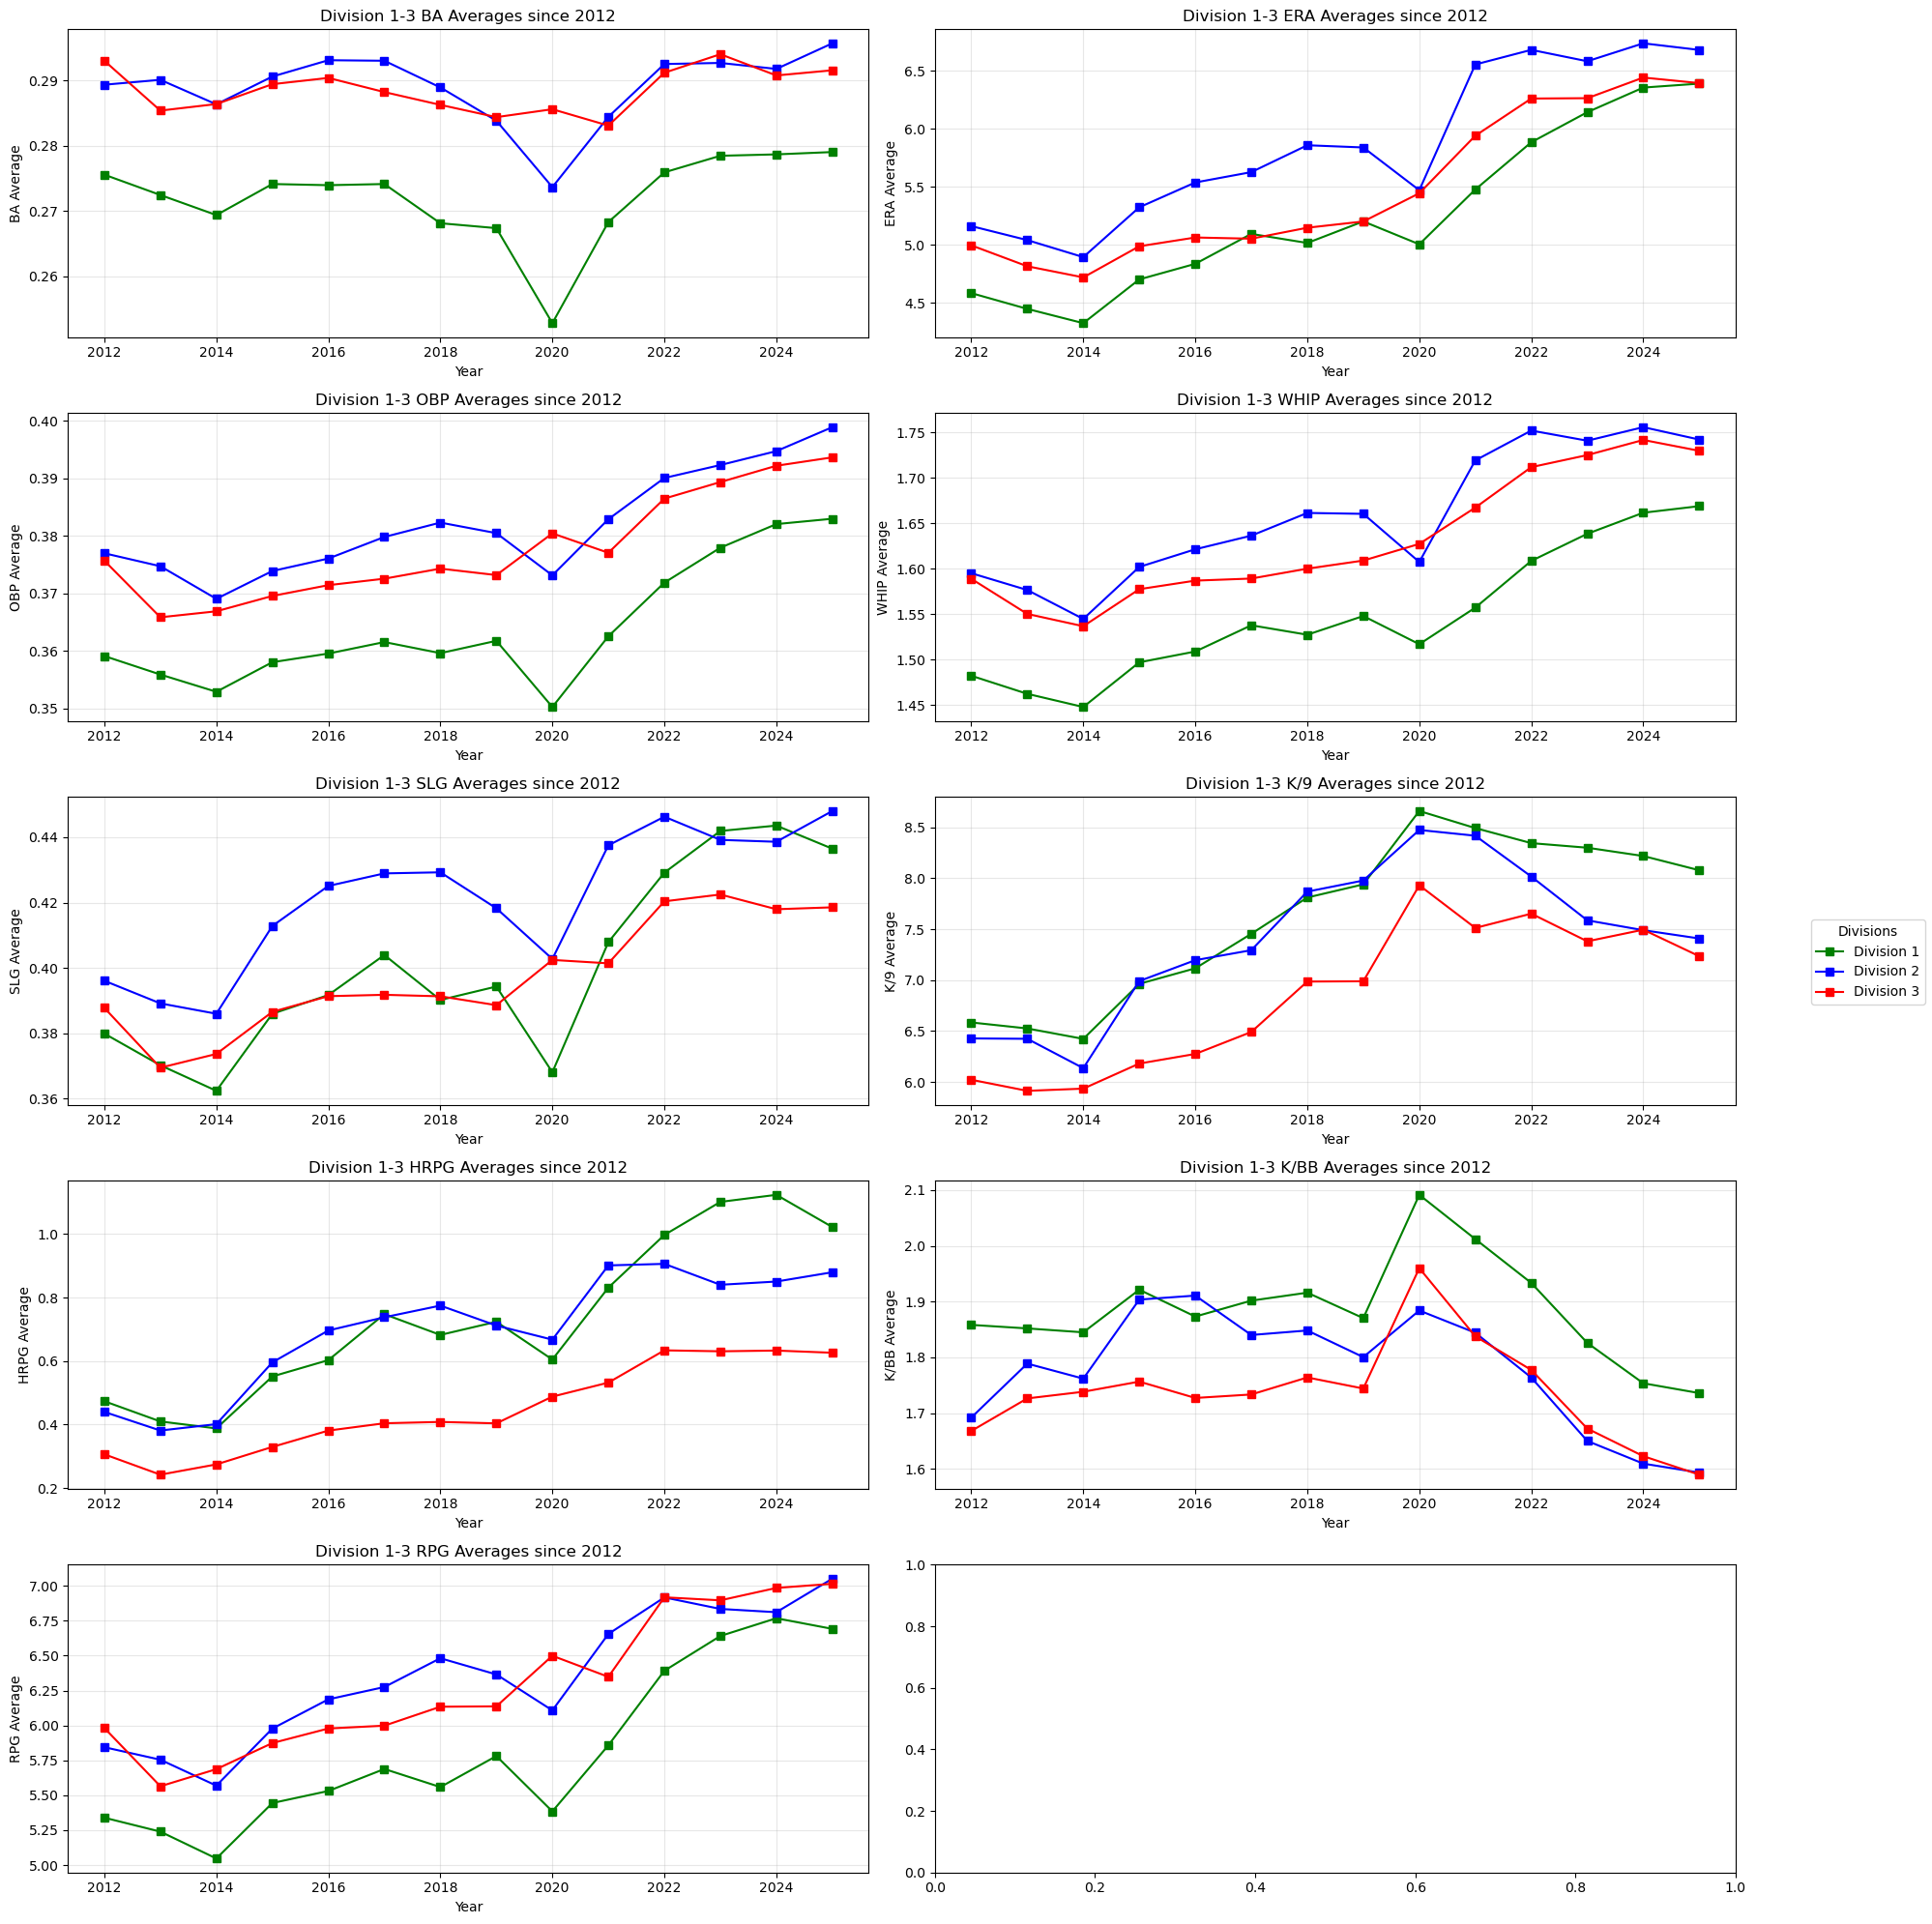

In [545]:
avg_metric_dict = {}
all_metrics = BAT_METRICS + PITCH_METRICS

# generate distinct colors for each metric
colors = cm.tab10(np.linspace(0, 1, len(all_metrics)))

fig, axes = plt.subplots(5, 2, figsize=(20, 20))
legend_handles = []

for i, metric in enumerate(all_metrics):
    years, avg1 = get_conf_trend(historic_division_stats[1], metric=metric, all_conf=True, div=1)
    years, avg2 = get_conf_trend(historic_division_stats[2], metric=metric, all_conf=True, div=2)
    years, avg3 = get_conf_trend(historic_division_stats[3], metric=metric, all_conf=True, div=3)
    avg_metric_dict['year'] = years
    avg_metric_dict[f'avg_{metric}_1'] = avg1
    avg_metric_dict[f'avg_{metric}_2'] = avg2
    avg_metric_dict[f'avg_{metric}_3'] = avg3

    if i < len(BAT_METRICS):
        x = i
        y = 0
    else:
        x = i - len(BAT_METRICS)
        y = 1

    l1, = axes[x, y].plot(years, avg1, marker='s', color='g', label=f'Division 1')
    l2, = axes[x, y].plot(years, avg2, marker='s', color='b', label=f'Division 2')
    l3, = axes[x, y].plot(years, avg3, marker='s', color='r', label=f'Division 3')
    axes[x, y].set_title(f'Division 1-3 {metric} Averages since 2012')
    axes[x, y].set_xlabel('Year')
    axes[x, y].set_ylabel(f'{metric} Average')
    axes[x, y].grid(True, alpha=0.3)

    if i == 0:
        legend_handles = [l1, l2, l3]

fig.legend(
    handles=legend_handles,
    labels=['Division 1', 'Division 2', 'Division 3'],
    loc='center right',
    title='Divisions'
)

plt.tight_layout()
plt.subplots_adjust(right=0.9)
#plt.savefig('Metric Average Plots.png', bbox_inches='tight', dpi=300)
plt.show()

avg_metric_df = pd.DataFrame(avg_metric_dict)

It's clear there is a strong correlation in average conference trends between batting and pitching metrics. WHIP and ERA seem to follow the same pattern that appears in all our batting metrics (HRPG is particularly close).

In [308]:
avg_metric_df

,year,avg_BA_1,avg_BA_2,avg_BA_3,avg_OBP_1,avg_OBP_2,avg_OBP_3,avg_SLG_1,avg_SLG_2,avg_SLG_3,...,avg_ERA_3,avg_WHIP_1,avg_WHIP_2,avg_WHIP_3,avg_K/9_1,avg_K/9_2,avg_K/9_3,avg_K/BB_1,avg_K/BB_2,avg_K/BB_3
0,2012,0.275571,0.289333,0.293000,0.359143,0.377000,0.375708,0.379929,0.396083,0.387792,...,4.997167,1.482393,1.595250,1.589083,6.584786,6.428000,6.022417,1.858286,1.692083,1.668083
1,2013,0.272464,0.290083,0.285375,0.355929,0.374750,0.365875,0.370250,0.389167,0.369500,...,4.816792,1.462500,1.576750,1.550417,6.525964,6.424417,5.913833,1.851964,1.788833,1.726458
2,2014,0.269393,0.286333,0.286375,0.352929,0.369083,0.366917,0.362429,0.386000,0.373708,...,4.720833,1.448000,1.544917,1.536917,6.423571,6.136417,5.935375,1.844964,1.761917,1.738375
3,2015,0.274143,0.290583,0.289417,0.358071,0.373917,0.369583,0.386000,0.412833,0.386583,...,4.989125,1.497179,1.602167,1.577667,6.963679,6.990833,6.181667,1.921393,1.903667,1.756583
4,2016,0.273964,0.293083,0.290375,0.359571,0.376083,0.371458,0.391714,0.425083,0.391375,...,5.064833,1.509071,1.621583,1.587083,7.116107,7.195833,6.275750,1.873250,1.910833,1.727250
5,2017,0.274143,0.293000,0.288208,0.361571,0.379833,0.372583,0.403964,0.428917,0.391792,...,5.054458,1.537929,1.636583,1.589375,7.454536,7.293833,6.491333,1.901786,1.840167,1.733500
6,2018,0.268143,0.288917,0.286250,0.359643,0.382333,0.374333,0.390214,0.429250,0.391333,...,5.149000,1.527536,1.661583,1.600250,7.810571,7.868667,6.986125,1.916071,1.848250,1.764042
7,2019,0.267393,0.283833,0.284375,0.361786,0.380500,0.373208,0.394321,0.418250,0.388625,...,5.202875,1.548143,1.660583,1.609167,7.939607,7.977500,6.988875,1.870429,1.800500,1.744167
8,2020,0.252857,0.273667,0.285583,0.350286,0.373167,0.380458,0.368107,0.402750,0.402458,...,5.446167,1.517107,1.607583,1.627500,8.659786,8.473583,7.930625,2.091536,1.884083,1.960042
9,2021,0.268321,0.284417,0.283083,0.362571,0.382917,0.377083,0.407893,0.437500,0.401417,...,5.942250,1.557357,1.719417,1.667458,8.492143,8.417083,7.512125,2.012143,1.844167,1.837750


Although the series is limited, we do see a sort of gradual descent in our ACF and a cut off around mark 1 in our PACF for our HRPG and WHIP metrics. Because of this, we will start our manual model using an Auto Regression with a lag of 1 and see how it fits our data.

## Manual Auto Regression

### Preprocessing

In [335]:
divison_1_df = pd.DataFrame(historic_division_stats[1])
divison_2_df = pd.DataFrame(historic_division_stats[2])
divison_3_df = pd.DataFrame(historic_division_stats[3])
divison_1_df

,GWC_2012,America_East_2012,Big_Ten_2012,Pac-12_2012,ACC_2012,Big_12_2012,Patriot_2012,CUSA_2012,SEC_2012,WCC_2012,...,Horizon_2025,America_East_2025,OVC_2025,NEC_2025,Summit_League_2025,SWAC_2025,WAC_2025,Mountain_West_2025,WCC_2025,Patriot_2025
BA,0.296,0.286,0.277,0.286,0.277,0.276,0.268,0.282,0.275,0.271,...,0.276,0.272,0.277,0.277,0.272,0.294,0.288,0.294,0.267,0.265
OBP,0.379,0.366,0.355,0.367,0.369,0.364,0.350,0.369,0.361,0.348,...,0.388,0.375,0.377,0.385,0.367,0.406,0.386,0.379,0.366,0.384
SLG,0.405,0.394,0.376,0.396,0.403,0.383,0.359,0.383,0.388,0.367,...,0.440,0.424,0.428,0.406,0.398,0.449,0.448,0.455,0.414,0.389
HRPG,0.429,0.403,0.463,0.507,0.613,0.479,0.310,0.488,0.578,0.406,...,1.080,0.943,1.002,0.698,0.750,0.893,1.054,0.985,0.989,0.573
RPG,6.043,5.500,5.345,5.591,5.883,5.433,4.950,5.444,5.283,4.822,...,6.950,6.229,6.650,6.337,5.900,7.417,6.833,6.700,5.989,6.150
ERA,6.079,5.633,4.081,3.775,3.845,3.780,4.578,3.953,3.589,3.682,...,7.823,6.457,6.284,8.240,6.690,8.533,6.217,6.539,6.350,6.513
WHIP,1.740,1.593,1.413,1.356,1.377,1.307,1.488,1.408,1.288,1.366,...,1.858,1.691,1.681,2.014,1.708,2.002,1.636,1.708,1.642,1.740
K/9,5.929,5.633,6.318,6.355,7.592,7.200,6.483,7.089,7.442,6.833,...,7.700,7.714,7.300,7.650,7.720,6.975,7.867,7.787,8.033,7.967
K/BB,1.534,1.637,1.972,1.993,2.084,2.397,1.705,1.946,2.567,2.069,...,1.297,1.614,1.637,1.221,1.662,1.124,1.922,1.786,1.716,1.493


In [130]:
# returns a conference's seasons
def get_conf_seasons(df, conf_='SEC_'):
    """
    Get conference DataFrame in Season by Season format
    
    Parameters:
        df:          division DataFrame (cols = ConfName_Year, rows = stats)
        conf_:       conference name (in underscore notation)
    """
    conf_cols = [col for col in df.columns if col.startswith(conf_)]
    conf_df = df[conf_cols]
    return conf_df

sec_season_stats = get_conf_seasons(conference_df, conf_='SEC_')
sec_season_stats

,SEC_2012,SEC_2013,SEC_2014,SEC_2015,SEC_2016,SEC_2017,SEC_2018,SEC_2019,SEC_2020,SEC_2021,SEC_2022,SEC_2023,SEC_2024,SEC_2025
BA,0.275,0.276,0.275,0.279,0.279,0.272,0.278,0.274,0.289,0.270,0.282,0.283,0.282,0.284
OBP,0.361,0.360,0.360,0.364,0.366,0.362,0.374,0.371,0.397,0.365,0.382,0.395,0.393,0.394
SLG,0.388,0.376,0.370,0.405,0.407,0.410,0.432,0.429,0.456,0.443,0.473,0.492,0.493,0.487
HRPG,0.578,0.499,0.450,0.701,0.709,0.854,1.032,1.046,1.150,1.277,1.457,1.609,1.664,1.531
RPG,5.283,5.300,5.257,5.643,5.936,5.750,6.293,6.479,7.543,6.393,7.050,7.407,7.314,7.294
ERA,3.589,3.410,3.258,3.770,3.817,3.987,4.149,4.158,2.859,4.494,4.621,5.159,5.039,4.796
WHIP,1.288,1.298,1.259,1.333,1.340,1.319,1.356,1.329,1.151,1.349,1.382,1.456,1.411,1.376
K/9,7.442,7.057,7.014,7.993,8.421,8.707,8.757,9.407,10.721,10.050,9.964,10.086,10.221,10.500
K/BB,2.567,2.233,2.274,2.343,2.520,2.477,2.416,2.559,3.308,2.764,2.576,2.348,2.536,2.704


In [453]:
def build_panel(df, metric, lag=1, div=1):
    """
    Reshape conference DataFrame into a long-format panel with lagged features.
    
    Returns a DataFrame like:
        year | conference | value | lag_1 | lag_2 | ...
    """
    rows = []
    for conf in CONFERENCE_DICT[div]:
        cols = sorted(
            [c for c in df.columns if c.startswith(f'{conf}_')],
            key=lambda c: int(c.split('_')[-1])
        )
        years = [int(c.split('_')[-1]) for c in cols]
        values = [float(df.loc[metric, c]) for c in cols]

        for i in range(lag, len(values)):
            row = {
                'year': years[i],
                'conference': conf,
                'value': values[i]
            }
            for l in range(1, lag + 1):
                row[f'lag_{l}'] = values[i - l]
            rows.append(row)

    return pd.DataFrame(rows)

In [455]:
df_panel = build_panel(divison_2_df, metric='HRPG', lag=1, div=2)
df_panel.head(20)

,year,conference,value,lag_1
0,2013,CACC,0.180,0.176
1,2014,CACC,0.209,0.180
2,2015,CACC,0.245,0.209
3,2016,CACC,0.361,0.245
4,2017,CACC,0.358,0.361
5,2018,CACC,0.343,0.358
6,2019,CACC,0.498,0.343
7,2020,CACC,0.406,0.498
8,2021,CACC,0.818,0.406
9,2022,CACC,0.767,0.818


This helper function creates lags for our AR model. It will allow us to easily tweak the hyper parameters of our model.

### Model Design

Here we build our Auto Regression model/visualization workflow. It returns model metrics found in our data along with projected changes in values overtime.

In [617]:
def panel_ar(df, metric, div=1, lag=1, test_years=2, forecast_years=3, display_stats=True, visualizations=False):
    """
    Fit an AR model on the full conference panel with conference dummies for analysis,
    and a separate division-average AR model for forecasting.

    Parameters:
        df:              conference DataFrame (cols = ConfName_Year, rows = stats)
        metric:          stat to model (e.g. 'BA')
        div:             division number (1, 2, or 3)
        test_years:      number of recent seasons to hold out
        forecast_years:  number of future seasons to predict
        display_stats:   print model summary
        visualizations:  show plots
    """
    # ============================================================
    # PANEL MODEL (for analysis & test evaluation)
    # ============================================================
    panel = build_panel(df, metric, lag, div=div)
    cutoff = panel['year'].max() - test_years + 1

    train = panel[panel['year'] < cutoff]
    test = panel[panel['year'] >= cutoff]

    lag_cols = [f'lag_{l}' for l in range(1, lag + 1)]
    train_dummies = pd.get_dummies(train['conference'], prefix='conf', drop_first=True)
    test_dummies = pd.get_dummies(test['conference'], prefix='conf', drop_first=True)
    test_dummies = test_dummies.reindex(columns=train_dummies.columns, fill_value=0)

    X_train = np.column_stack([np.ones(len(train)), train[lag_cols].values, train_dummies.values])
    y_train = train['value'].values
    X_test = np.column_stack([np.ones(len(test)), test[lag_cols].values, test_dummies.values])
    y_test = test['value'].values

    coeffs = np.linalg.solve(X_train.T @ X_train, X_train.T @ y_train)
    y_pred_train = X_train @ coeffs
    y_pred_test = X_test @ coeffs

    train_residuals = y_train - y_pred_train
    train_rmse = np.sqrt(np.mean(train_residuals ** 2))
    test_rmse = np.sqrt(np.mean((y_test - y_pred_test) ** 2))

    # ============================================================
    # DIVISION-AVERAGE AR MODEL (for forecasting)
    # ============================================================
    yearly_avg = panel.groupby('year')['value'].mean().sort_index()
    avg_years = yearly_avg.index.values
    avg_values = yearly_avg.values

    # build lagged matrix on the division averages directly
    # includes a linear time trend to capture non-stationary growth
    n = len(avg_values)
    time_index = np.arange(n, dtype=float)
    X_avg = np.ones((n - lag, lag + 2))  # +2 for intercept and trend
    X_avg[:, 1] = time_index[lag:]       # trend column
    y_avg = avg_values[lag:]
    for i in range(lag):
        X_avg[:, i + 2] = avg_values[lag - i - 1 : n - i - 1]

    # split the average series the same way
    avg_cutoff_idx = np.searchsorted(avg_years[lag:], cutoff)
    X_avg_train = X_avg[:avg_cutoff_idx]
    y_avg_train = y_avg[:avg_cutoff_idx]
    X_avg_test = X_avg[avg_cutoff_idx:]
    y_avg_test = y_avg[avg_cutoff_idx:]

    # fit AR on division averages
    avg_coeffs = np.linalg.solve(X_avg_train.T @ X_avg_train, X_avg_train.T @ y_avg_train)
    avg_fitted = X_avg_train @ avg_coeffs
    avg_pred_test = X_avg_test @ avg_coeffs
    avg_residuals = y_avg_train - avg_fitted
    residual_std = np.std(avg_residuals)

    # forecast using the division-average AR model
    # use actual observed values (not fitted) as the launch point
    history = list(avg_values)
    forecast_vals = []
    forecast_stds = []
    current_time = float(n - 1)

    for step in range(1, forecast_years + 1):
        current_time += 1
        lags = [history[-i] for i in range(1, lag + 1)]
        y_hat = avg_coeffs[0] + avg_coeffs[1] * current_time + np.dot(avg_coeffs[2:], lags)
        forecast_vals.append(y_hat)
        forecast_stds.append(residual_std * np.sqrt(step))
        history.append(y_hat)

    forecast_vals = np.array(forecast_vals)
    forecast_stds = np.array(forecast_stds)
    last_year = int(avg_years[-1])
    forecast_year_labels = [last_year + i for i in range(1, forecast_years + 1)]

    # ============================================================
    # PRINT SUMMARY
    # ============================================================
    summary_lines = [
        f"Panel AR({lag}) for Division {div} {metric}",
        "=" * 50,
        f"  --- Panel Model (conference-level) ---",
        f"  {'Intercept':<12} {coeffs[0]:.6f}",
    ]
    for i in range(lag):
        summary_lines.append(f"  {'lag_' + str(i+1):<12} {coeffs[i+1]:.6f}")
    summary_lines += [
        f"  Train RMSE:  {train_rmse:.4f}",
        f"  Test RMSE:   {test_rmse:.4f}",
        "",
        f"  --- Division Avg AR (for forecasting) ---",
        f"  {'Intercept':<12} {avg_coeffs[0]:.6f}",
        f"  {'Trend':<12} {avg_coeffs[1]:.6f}",
    ]
    for i in range(lag):
        summary_lines.append(f"  {'lag_' + str(i+1):<12} {avg_coeffs[i+2]:.6f}")
    summary_lines.append(f"  Residual Std: {residual_std:.4f}")
    summary_lines.append(f"  Forecast:")
    for year, val in zip(forecast_year_labels, forecast_vals):
        summary_lines.append(f"    {year}:     {val:.4f}")
    summary_lines.append("=" * 50)

    summary = '\n'.join(summary_lines)
    if display_stats:
        print(summary)

    # ============================================================
    # BUILD RESULT DATAFRAMES
    # ============================================================
    train_result = train[['year', 'value']].copy()
    train_result['predicted'] = y_pred_train
    train_yearly = train_result.groupby('year')[['value', 'predicted']].mean().reset_index()

    test_result = test[['year', 'conference', 'value']].copy()
    test_result['predicted'] = y_pred_test
    test_yearly = test_result.groupby('year')[['value', 'predicted']].mean().reset_index()

    if visualizations:
        all_yearly = pd.concat([train_yearly, test_yearly]).sort_values('year')

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # [0,0] residuals scatter
        axes[0].scatter(y_pred_train, train_residuals, alpha=0.5, color='steelblue')
        axes[0].axhline(0, color='black', linewidth=0.8)
        axes[0].set_title(f'Division {div} Residuals vs Predicted')
        axes[0].set_xlabel('Predicted')
        axes[0].set_ylabel('Residual')
        axes[0].grid(True, alpha=0.3)

        # [0,1] full timeline + forecast with confidence bands
        # plot division averages (actual trend line the AR model was fit on)
        axes[1].plot(avg_years, avg_values, 'o-', label='Division Avg (Actual)', color='steelblue')
        # plot fitted values from the avg AR model on training period
        axes[1].plot(avg_years[lag:lag + len(avg_fitted)], avg_fitted, 'x--',
                        label='Fitted (Avg AR)', color='orange', alpha=0.7)
        # connect actual to forecast plot line
        axes[1].plot([avg_years[-1], forecast_year_labels[0]], 
             [avg_values[-1], forecast_vals[0]], 
             '--', color='green', alpha=0.5)
        # plot test predictions from avg AR model
        if len(avg_pred_test) > 0:
            axes[1].plot(avg_years[lag + avg_cutoff_idx:], avg_pred_test, 'o--',
                            label='Predicted (Test)', color='coral')
        # forecast
        axes[1].plot(forecast_year_labels, forecast_vals, 's--', label='Forecast', color='green')
        axes[1].fill_between(
            forecast_year_labels,
            forecast_vals - 1.96 * forecast_stds,
            forecast_vals + 1.96 * forecast_stds,
            alpha=0.2, color='green', label='95% CI'
        )
        axes[1].fill_between(
            forecast_year_labels,
            forecast_vals - forecast_stds,
            forecast_vals + forecast_stds,
            alpha=0.3, color='green', label='68% CI'
        )
        axes[1].axvline(cutoff - 0.5, color='gray', linestyle=':', alpha=0.7, label='Train/Test Split')
        axes[1].set_title(f'Division {div} {metric} Avg — AR({lag}) Fit + Forecast')
        axes[1].set_xlabel('Year')
        axes[1].set_ylabel(metric)
        axes[1].legend(fontsize=7)
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    return panel, coeffs, avg_coeffs, test_result, summary

In [579]:
def panel_ma(df, metric, div=1, order=(0,0,1), test_years=2, forecast_years=3, display_stats=True, visualizations=False):
    """
    Fit an MA/ARIMA model on the division-average time series,
    with a panel model for conference-level analysis.
    
    Parameters:
        df:              conference DataFrame (cols = ConfName_Year, rows = stats)
        metric:          stat to model (e.g. 'BA')
        div:             division number (1, 2, or 3)
        order:           ARIMA order tuple (p, d, q) — default (0,0,1) for MA(1)
        test_years:      number of recent seasons to hold out
        forecast_years:  number of future seasons to predict
        display_stats:   print model summary
        visualizations:  show plots
    """
    # ============================================================
    # PANEL MODEL (for analysis & test evaluation)
    # ============================================================
    p, d, q = order
    
    # at least 1 lag for the panel model
    panel_lag = max(p, 1)
    panel = build_panel(df, metric, lag=panel_lag, div=div)
    cutoff = panel['year'].max() - test_years + 1

    # define train/test split
    train = panel[panel['year'] < cutoff]
    test = panel[panel['year'] >= cutoff]

    # define train/test dummies
    # this allows us to weight metrics differently based on a conference coeff
    # EX. a 3.5 average ERA in the SEC might be weighted differently than in the Big 10 
    lag_cols = [f'lag_{l}' for l in range(1, panel_lag + 1)]
    train_dummies = pd.get_dummies(train['conference'], prefix='conf', drop_first=True)
    test_dummies = pd.get_dummies(test['conference'], prefix='conf', drop_first=True)
    test_dummies = test_dummies.reindex(columns=train_dummies.columns, fill_value=0)

    # X/y train/test splits
    X_train = np.column_stack([np.ones(len(train)), train[lag_cols].values, train_dummies.values])
    y_train = train['value'].values
    X_test = np.column_stack([np.ones(len(test)), test[lag_cols].values, test_dummies.values])
    y_test = test['value'].values

    # solve closed form solution
    coeffs = np.linalg.solve(X_train.T @ X_train, X_train.T @ y_train)
    y_pred_train = X_train @ coeffs
    y_pred_test = X_test @ coeffs

    # calculate results
    train_residuals = y_train - y_pred_train
    train_rmse = np.sqrt(np.mean(train_residuals ** 2))
    test_rmse = np.sqrt(np.mean((y_test - y_pred_test) ** 2))

    # ============================================================
    # DIVISION-AVERAGE MA/ARIMA MODEL (for forecasting)
    # ============================================================
    # group and sort metrics averages by year
    yearly_avg = panel.groupby('year')['value'].mean().sort_index()
    avg_years = yearly_avg.index.values
    avg_values = yearly_avg.values

    # split for train/test for averages
    avg_cutoff_idx = np.searchsorted(avg_years, cutoff)
    avg_train = avg_values[:avg_cutoff_idx]
    avg_test = avg_values[avg_cutoff_idx:]
    avg_test_years = avg_years[avg_cutoff_idx:]

    # fit ARIMA training data for test evaluation
    train_model = ARIMA(avg_train, order=order).fit()
    avg_pred_test = train_model.forecast(steps=len(avg_test))

    # refit on full series for final forecast
    full_model = ARIMA(avg_values, order=order).fit()
    forecast_obj = full_model.get_forecast(steps=forecast_years)
    forecast_vals = np.array(forecast_obj.predicted_mean)
    forecast_ci_95 = np.array(forecast_obj.conf_int(alpha=0.05))
    forecast_ci_68 = np.array(forecast_obj.conf_int(alpha=0.32))

    # get result/forecast metrics
    avg_fitted = full_model.fittedvalues
    residual_std = np.std(avg_values - avg_fitted)
    last_year = int(avg_years[-1])
    forecast_year_labels = [last_year + i for i in range(1, forecast_years + 1)]
    arima_test_rmse = np.sqrt(np.mean((avg_test - avg_pred_test) ** 2))

    # model label
    p, d, q = order
    model_name = []
    if p > 0: model_name.append(f'AR({p})')
    if d > 0: model_name.append(f'I({d})')
    if q > 0: model_name.append(f'MA({q})')
    model_label = '+'.join(model_name) if model_name else f'ARIMA{order}'

    # ============================================================
    # PRINT SUMMARY
    # ============================================================
    summary_lines = [
        f"Panel + ARIMA{order} for Division {div} {metric}",
        "=" * 50,
        f"  --- Panel Model (conference-level) ---",
        f"  {'Intercept':<12} {coeffs[0]:.6f}",
    ]
    for i in range(panel_lag):
        summary_lines.append(f"  {'lag_' + str(i+1):<12} {coeffs[i+1]:.6f}")
    summary_lines += [
        f"  Train RMSE:  {train_rmse:.4f}",
        f"  Test RMSE:   {test_rmse:.4f}",
        "",
        f"  --- Division Avg {model_label} (for forecasting) ---",
        f"  AIC:          {full_model.aic:.4f}",
        f"  Test RMSE:    {arima_test_rmse:.4f}",
        f"  Residual Std: {residual_std:.4f}",
        f"  Params:",
    ]
    for name, val in zip(full_model.param_names, full_model.params):
        summary_lines.append(f"    {name:<16} {val:.6f}")
    summary_lines.append("")
    summary_lines.append(f"  Forecast:")
    for year, val in zip(forecast_year_labels, forecast_vals):
        summary_lines.append(f"    {year}:     {val:.4f}")
    summary_lines.append("=" * 50)
    
    summary = '\n'.join(summary_lines)
    if display_stats:
        print(summary)

    # ============================================================
    # BUILD RESULT DATAFRAMES
    # ============================================================
    train_result = train[['year', 'value']].copy()
    train_result['predicted'] = y_pred_train
    train_yearly = train_result.groupby('year')[['value', 'predicted']].mean().reset_index()

    test_result = test[['year', 'conference', 'value']].copy()
    test_result['predicted'] = y_pred_test
    test_yearly = test_result.groupby('year')[['value', 'predicted']].mean().reset_index()

    if visualizations:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # [0] residuals scatter
        axes[0].scatter(y_pred_train, train_residuals, alpha=0.5, color='steelblue')
        axes[0].axhline(0, color='black', linewidth=0.8)
        axes[0].set_title(f'Division {div} Residuals vs Predicted')
        axes[0].set_xlabel('Predicted')
        axes[0].set_ylabel('Residual')
        axes[0].grid(True, alpha=0.3)

        # [1] full timeline + forecast with confidence bands
        axes[1].plot(avg_years, avg_values, 'o-', label='Division Avg (Actual)', color='steelblue')
        axes[1].plot(avg_years, avg_fitted, 'x--', label=f'Fitted ({model_label})', color='orange', alpha=0.7)
        # connect actual to forecast
        axes[1].plot([avg_years[-1], forecast_year_labels[0]],
                     [avg_values[-1], forecast_vals[0]],
                     '--', color='green', alpha=0.5)
        # test predictions
        if len(avg_pred_test) > 0:
            axes[1].plot(avg_test_years, avg_pred_test, 'o--', label='Predicted (Test)', color='coral')
        # forecast
        axes[1].plot(forecast_year_labels, forecast_vals, 's--', label='Forecast', color='green')
        axes[1].fill_between(
            forecast_year_labels,
            forecast_ci_95[:, 0], forecast_ci_95[:, 1],
            alpha=0.2, color='green', label='95% CI'
        )
        axes[1].fill_between(
            forecast_year_labels,
            forecast_ci_68[:, 0], forecast_ci_68[:, 1],
            alpha=0.3, color='green', label='68% CI'
        )
        axes[1].axvline(cutoff - 0.5, color='gray', linestyle=':', alpha=0.7, label='Train/Test Split')
        axes[1].set_title(f'Division {div} {metric} Avg — {model_label} Fit + Forecast')
        axes[1].set_xlabel('Year')
        axes[1].set_ylabel(metric)
        axes[1].legend(fontsize=7)
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    return panel, coeffs, full_model, test_result, summary

Since we are mainly interested to see if there is an increase in swinging for home runs and pitchers striking out batters, lets focus on the following relationships between metrics at each level.

#### HRPG vs ERA

Are pitchers able to keep up with the increase of power from batters?

First, like in any time series setting, lets look at our ACF and PACF plots to see where our lag should start (in the interest of not using excess space, I will only show the division 1 ACF and PACF plots, take my word for it they mirror the pattern below).

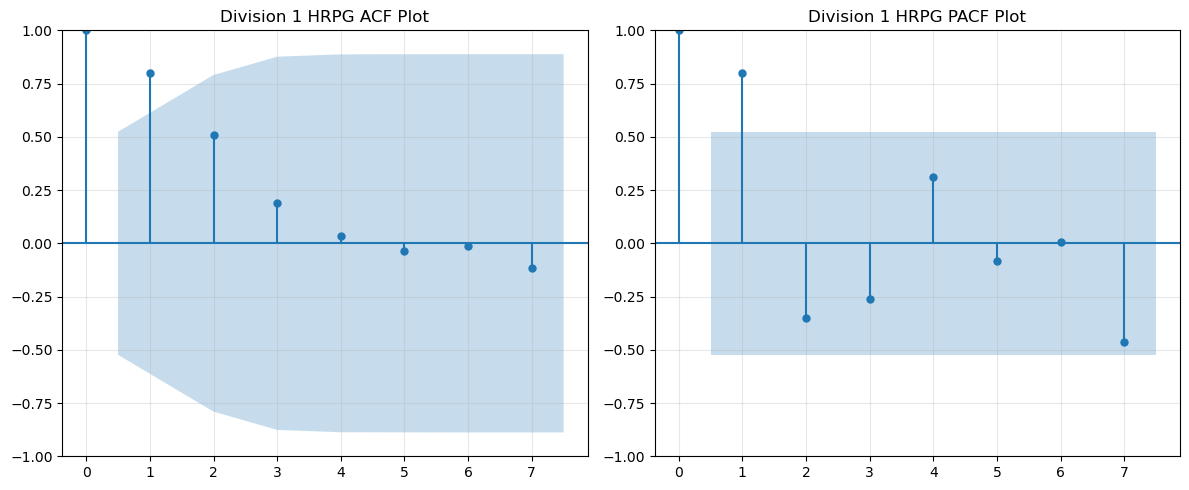

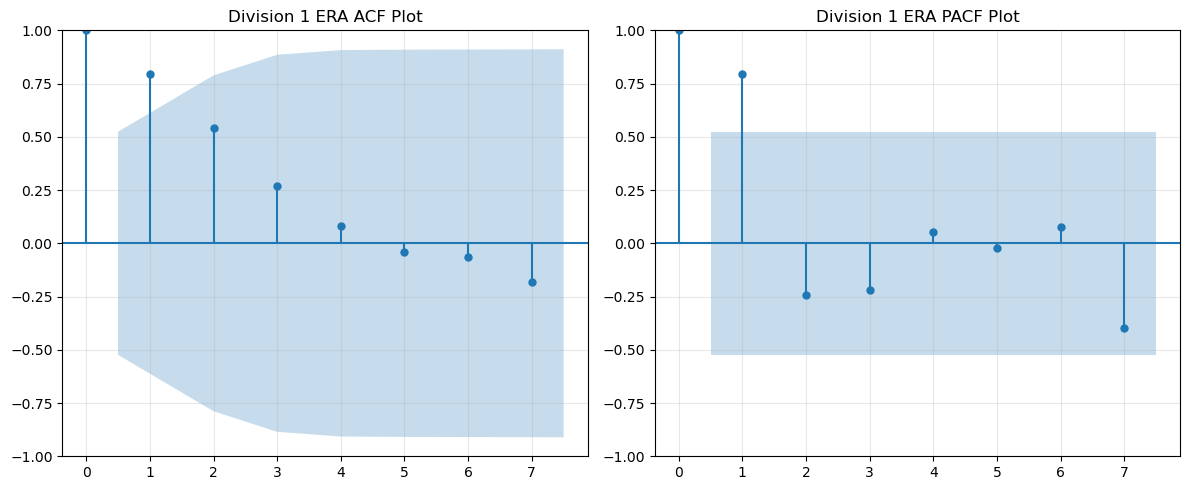

In [549]:
get_acf_pacf(metric='HRPG', metric_df=avg_metric_df, div=1)
get_acf_pacf(metric='ERA', metric_df=avg_metric_df, div=1)

Although the series is limited, we do see a sort of gradual descent in our ACF and a cut off around mark 1 in our PACF for our HRPG and ERA metrics. Because of this, we will start our manual model using Auto Regression with a lag of 1 and see how it fits our data.

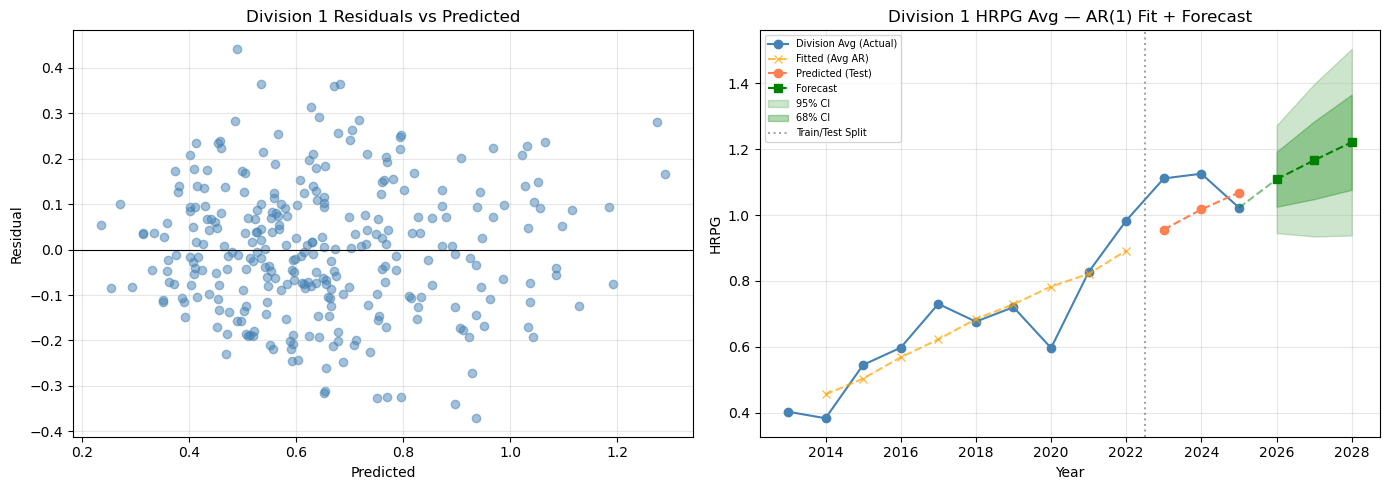

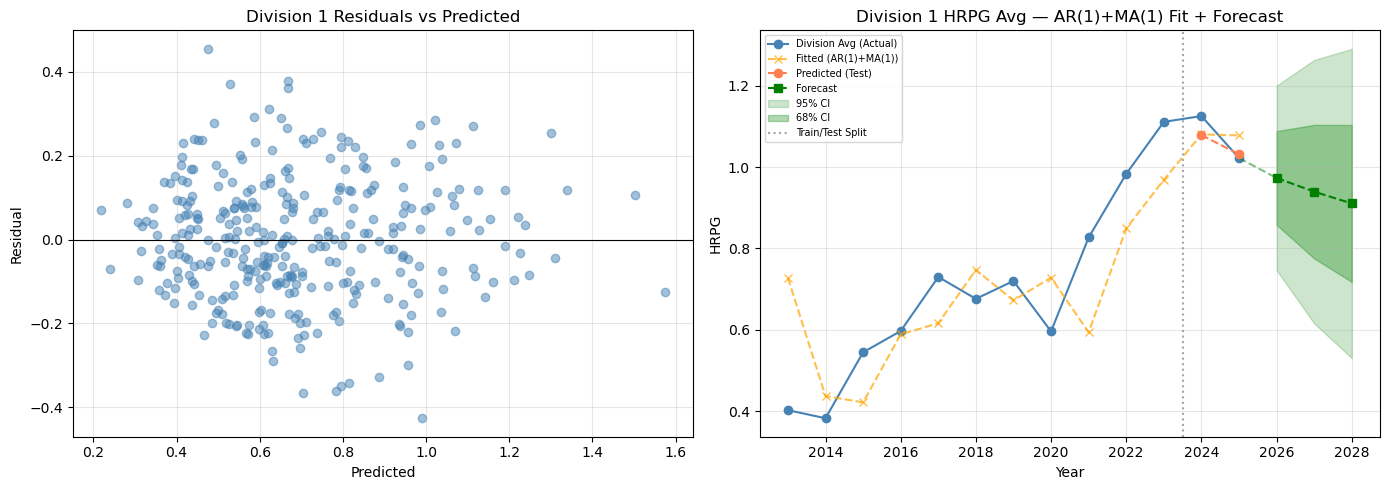

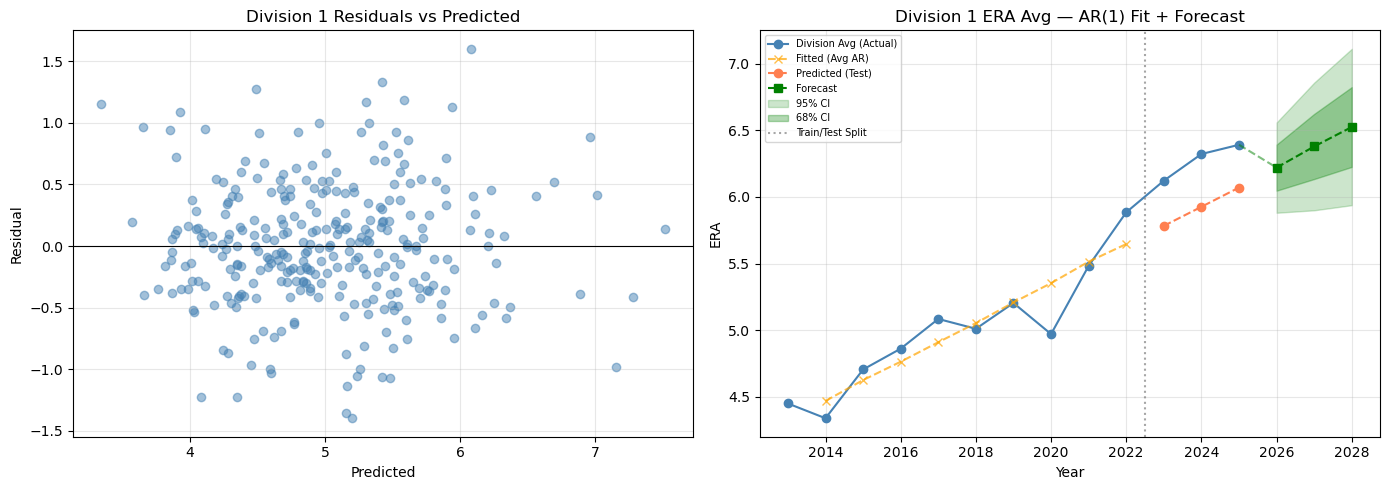

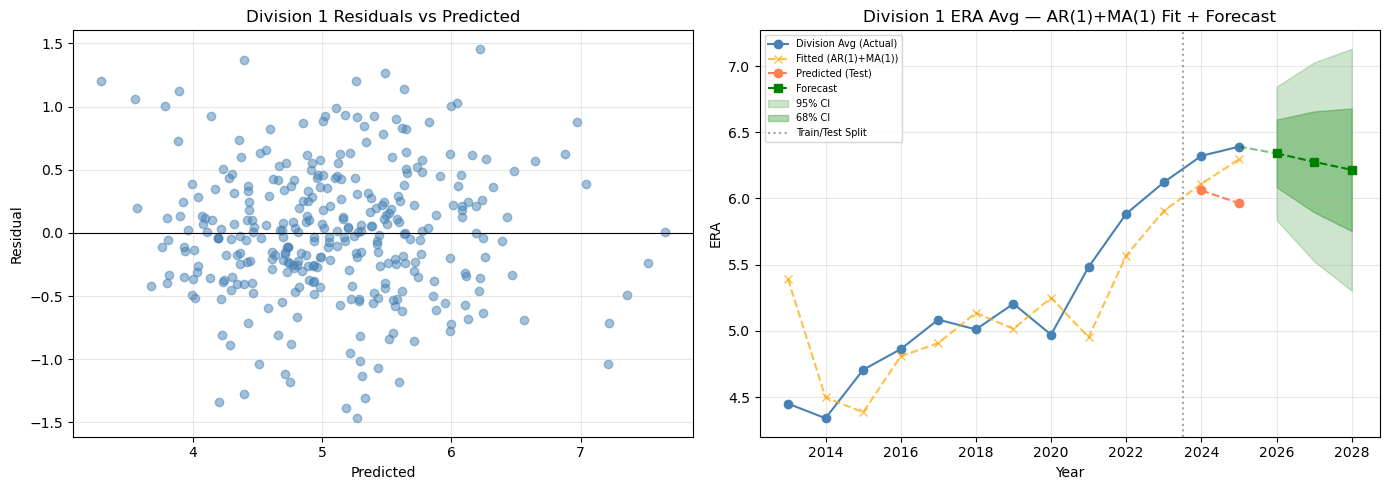

In [621]:
ar_HRPG_div1 = list(panel_ar(divison_1_df, 'HRPG', div=1, lag=1, test_years=3, forecast_years=3, display_stats=False, visualizations=True))
arima_HRPG_div1 = list(panel_ma(divison_1_df, 'HRPG', div=1, order=(1,0,1), display_stats=False, visualizations=True))

ar_ERA_div1 = list(panel_ar(divison_1_df, 'ERA', div=1, lag=1, test_years=3, forecast_years=3, display_stats=False, visualizations=True))
arima_ERA_div1 = list(panel_ma(divison_1_df, 'ERA', div=1, order=(1,0,1), display_stats=False, visualizations=True))

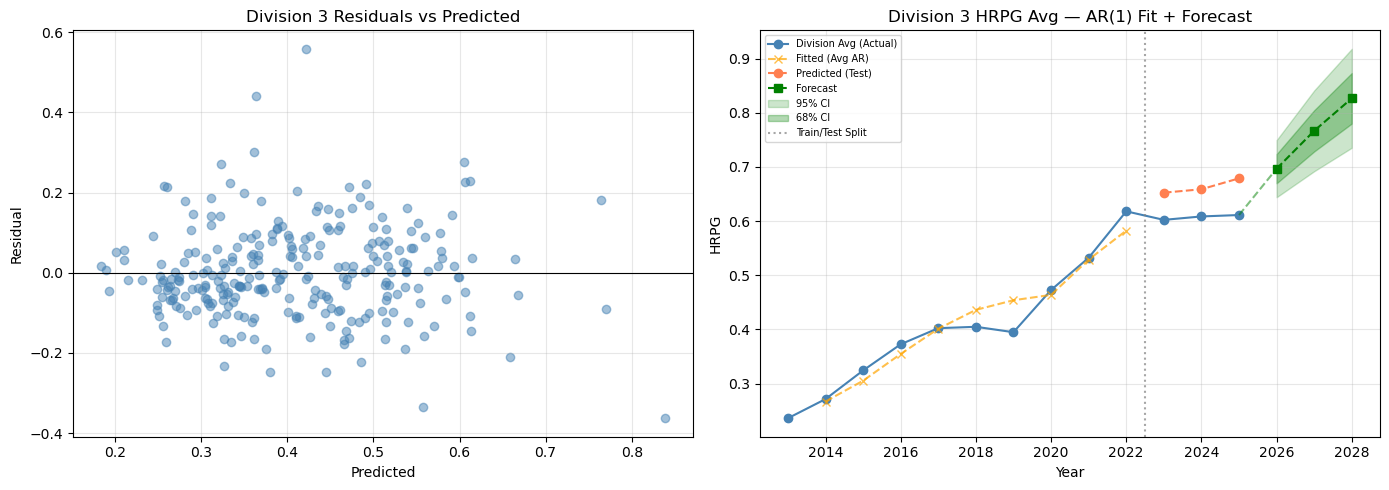

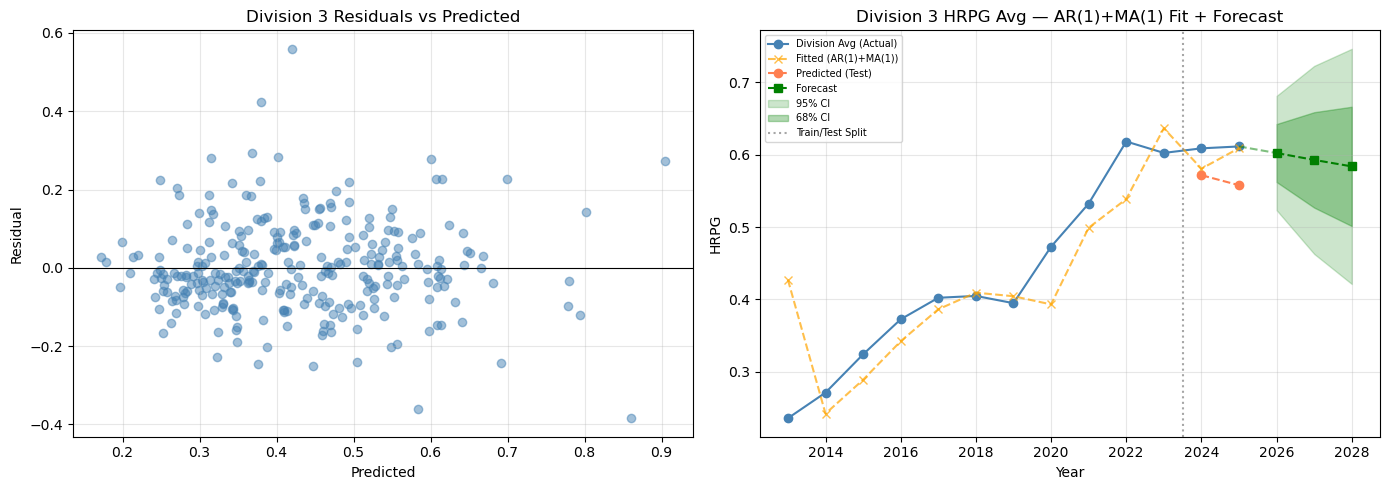

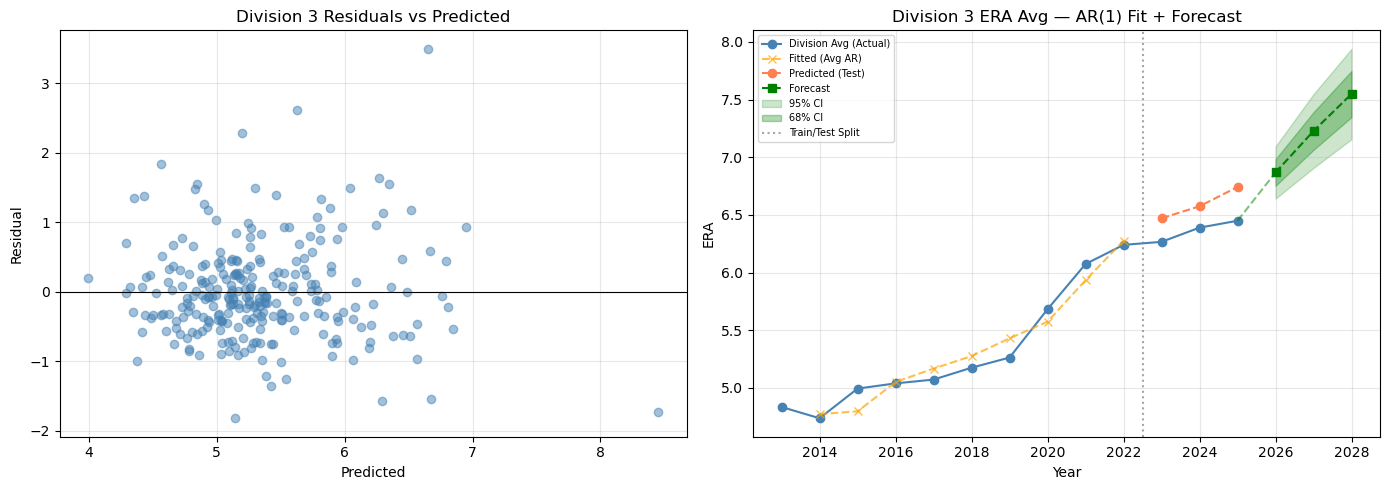

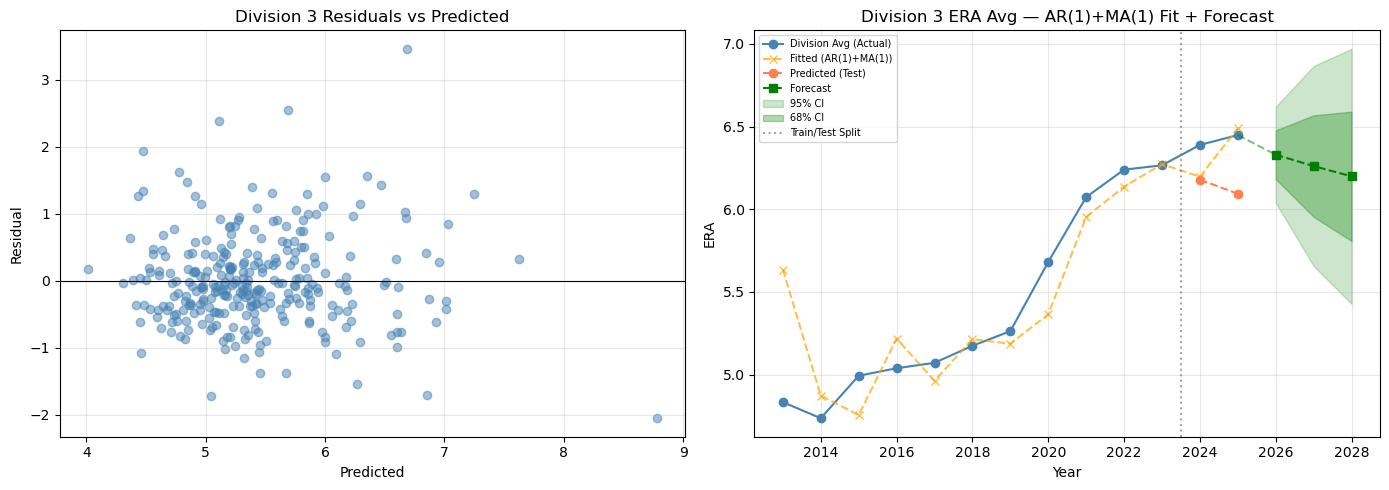

In [627]:
ar_HRPG_div1 = list(panel_ar(divison_3_df, 'HRPG', div=3, lag=1, test_years=3, forecast_years=3, display_stats=False, visualizations=True))
arima_HRPG_div1 = list(panel_ma(divison_3_df, 'HRPG', div=3, order=(1,0,1), display_stats=False, visualizations=True))

ar_ERA_div1 = list(panel_ar(divison_3_df, 'ERA', div=3, lag=1, test_years=3, forecast_years=3, display_stats=False, visualizations=True))
arima_ERA_div1 = list(panel_ma(divison_3_df, 'ERA', div=3, order=(1,0,1), display_stats=False, visualizations=True))

In [623]:
print(ar_HRPG_div1[4])
print(arima_HRPG_div1[4])

print(ar_ERA_div1[4])
print(arima_ERA_div1[4])

Panel AR(1) for Division 1 HRPG
  --- Panel Model (conference-level) ---
  Intercept    0.228881
  lag_1        0.831626
  Train RMSE:  0.1442
  Test RMSE:   0.1501

  --- Division Avg AR (for forecasting) ---
  Intercept    0.368963
  Trend        0.049786
  lag_1        0.090498
  Residual Std: 0.0835
  Forecast:
    2026:     1.1087
    2027:     1.1663
    2028:     1.2213
Panel + ARIMA(1, 0, 1) for Division 1 HRPG
  --- Panel Model (conference-level) ---
  Intercept    0.147958
  lag_1        0.917108
  Train RMSE:  0.1457
  Test RMSE:   0.1527

  --- Division Avg AR(1)+MA(1) (for forecasting) ---
  AIC:          -9.5082
  Test RMSE:    0.0337
  Residual Std: 0.1403
  Params:
    const            0.727734
    ar.L1            0.862964
    ma.L1            0.153726
    sigma2           0.013423

  Forecast:
    2026:     0.9732
    2027:     0.9395
    2028:     0.9105
Panel AR(1) for Division 1 ERA
  --- Panel Model (conference-level) ---
  Intercept    1.864496
  lag_1        0.5

Our predictions show a strong correlation between HRPG and ERA, with our model having both metrics rapidly increase over the next 3 years. This trend is very intuitive due to the nature of both statistics (if more home runs and scored, more pitchers are giving up runs). This mirrors our prior belief that batters are swinging for the fences, however we still need to find out if pitchers despite this universal increase in ERA are projected for more strikeouts.

#### HRPG vs K/9

Does the "three true outcomes" (strikeout, walk, home run) theory apply to college baseball?

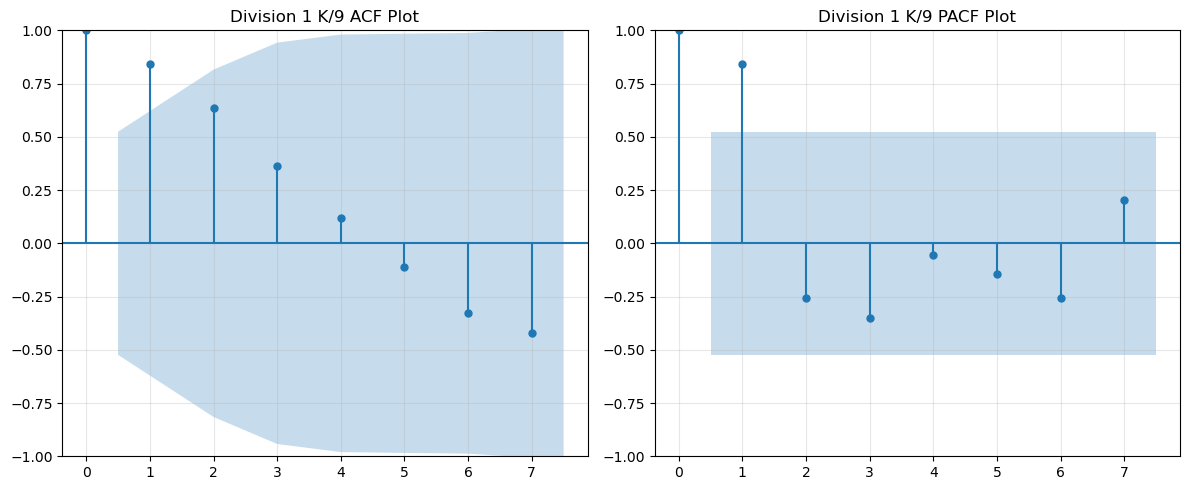

In [488]:
get_acf_pacf(metric='K/9', metric_df=avg_metric_df, div=1)

Panel AR(1) for K/9
  --- Panel Model (conference-level) ---
  Intercept    1.943896
  lag_1        0.795827
  Train RMSE:  0.4919
  Test RMSE:   0.3303

  --- Division Avg AR (for forecasting) ---
  Intercept    3.521448
  Trend        0.103181
  lag_1        0.483060
  Residual Std: 0.2488
  Forecast:
  2026:     8.765
  2027:     9.2
  2028:     9.5133


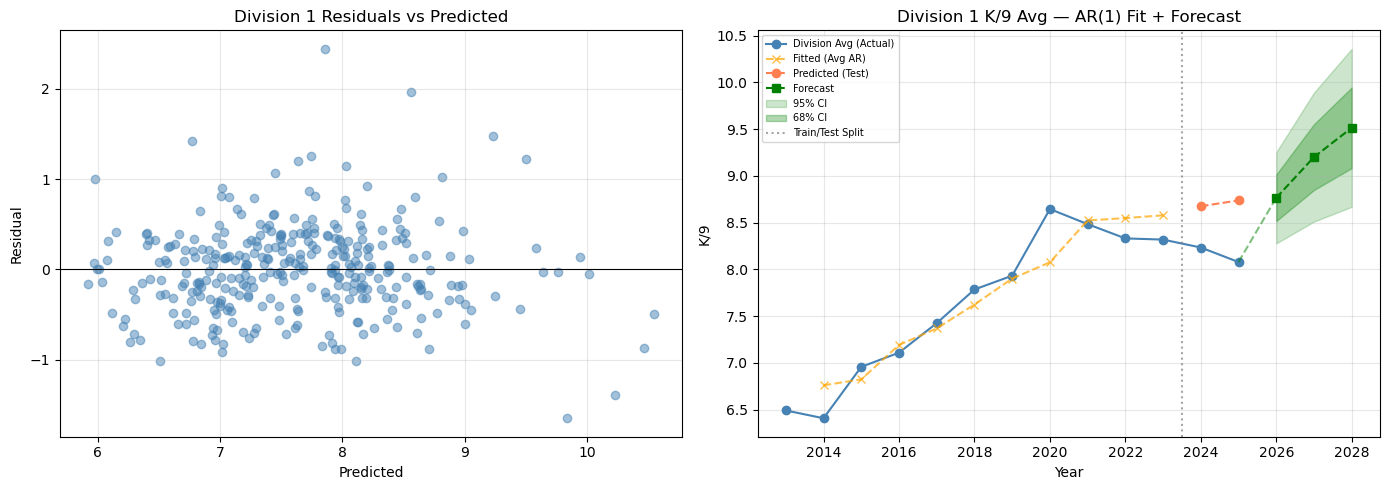

Panel + ARIMA(1, 0, 1) for Division 1 K/9
  --- Panel Model (conference-level) ---
  Intercept    1.943896
  lag_1        0.795827
  Train RMSE:  0.4919
  Test RMSE:   0.3303

  --- Division Avg AR(1)+MA(1) (for forecasting) ---
  AIC:          15.3438
  Test RMSE:    0.0546
  Residual Std: 0.3883
  Params:
    const            7.479205
    ar.L1            0.885014
    ma.L1            0.214497
    sigma2           0.088834

  Forecast:
    2026:     7.9948
    2027:     7.9355
    2028:     7.8831


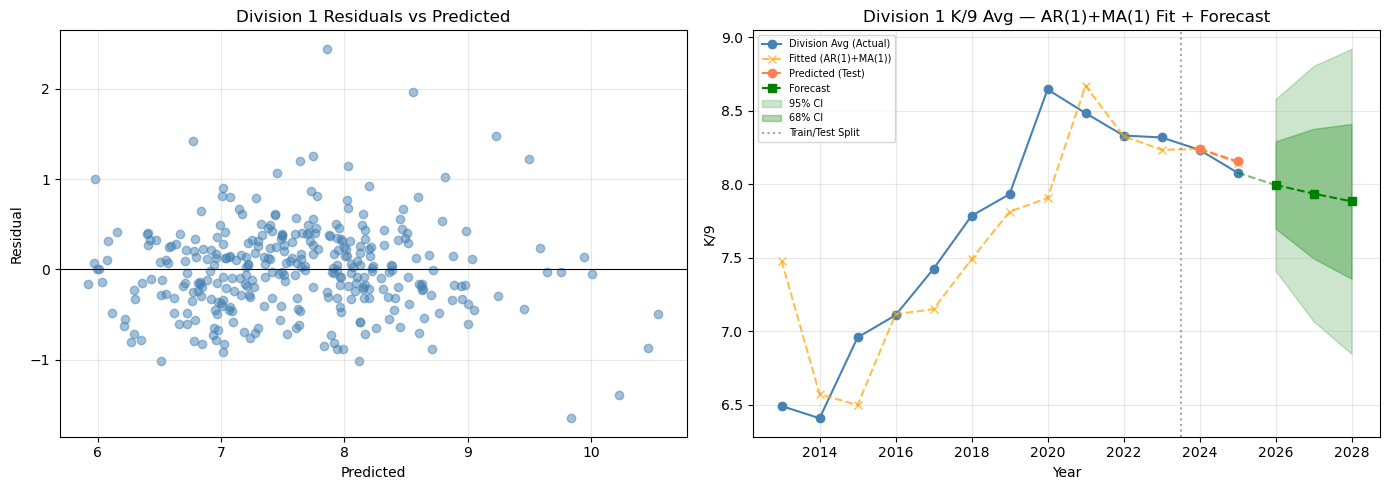

In [577]:
panel, coeffs, avg_coeffs, results = panel_ar(divison_1_df, 'K/9', div=1, lag=1, test_years=2, forecast_years=3, display_stats=True, visualizations=True)
# compare with ARIMA(1,0,1)
panel, coeffs, full_model, results = panel_ma(divison_1_df, 'K/9', div=1, order=(1,0,1), display_stats=True, visualizations=True)

#### HRPG vs BA

Are players in college sacrificing making contact at the expense of their batting average for higher swinging power?

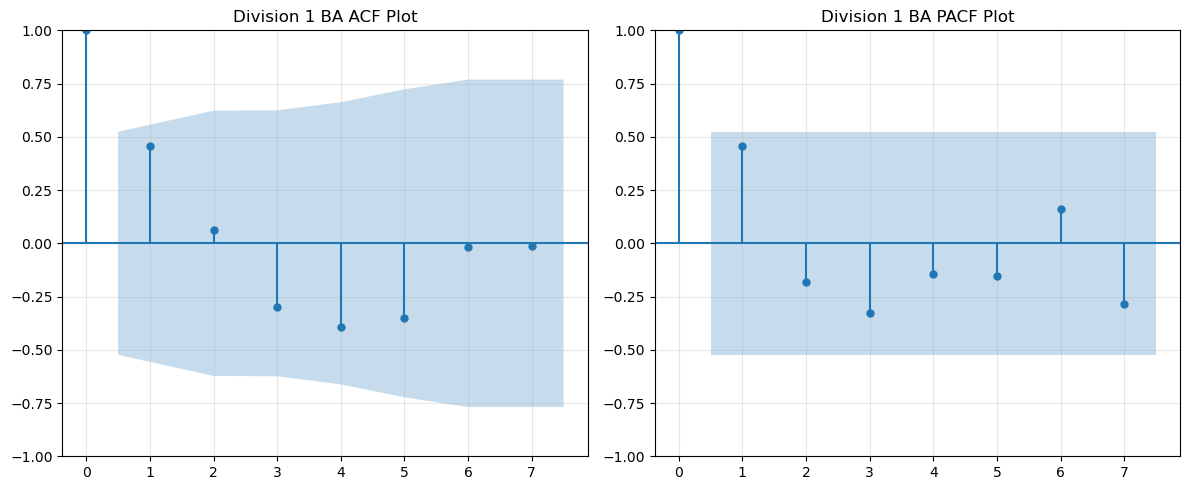

In [503]:
get_acf_pacf(metric='BA', metric_df=avg_metric_df, div=1)

Panel AR(1) for BA
  --- Panel Model (conference-level) ---
  Intercept    0.239078
  lag_1        0.138579
  Train RMSE:  0.0098
  Test RMSE:   0.0098

  --- Division Avg AR (for forecasting) ---
  Intercept    0.169581
  Trend        0.000312
  lag_1        0.366905
  Residual Std: 0.0065
  Forecast:
  2026:     0.276
  2027:     0.2752
  2028:     0.2752


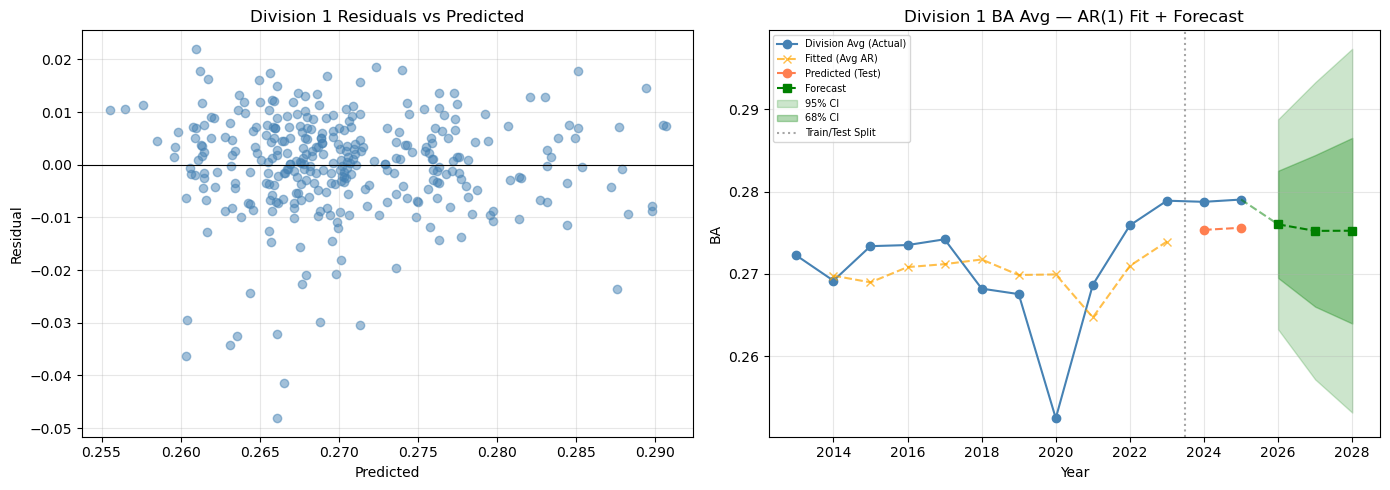

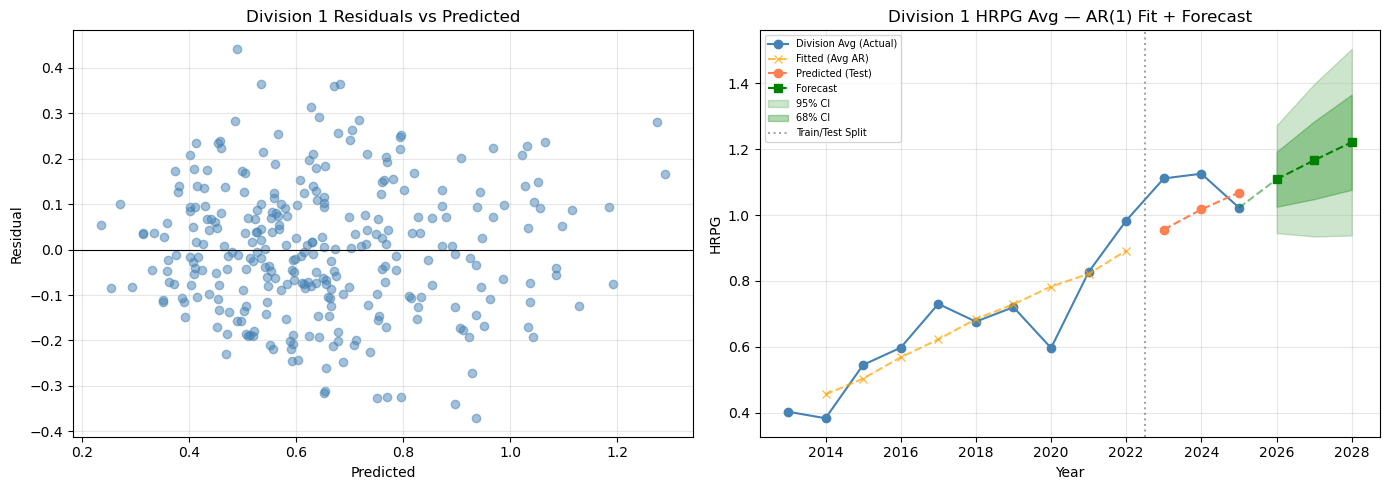

In [505]:
panel, coeffs, avg_coeffs, results = panel_ar(divison_1_df, 'BA', div=1, lag=1, test_years=2, forecast_years=3, display_stats=True, visualizations=True)
panel, coeffs, avg_coeffs, results = panel_ar(divison_1_df, 'HRPG', div=1, lag=1, test_years=3, forecast_years=3, display_stats=False, visualizations=True)

#### HRPG vs WHIP

Are pitchers managing baserunners at the expense of giving up more damage when a batter does make contact?

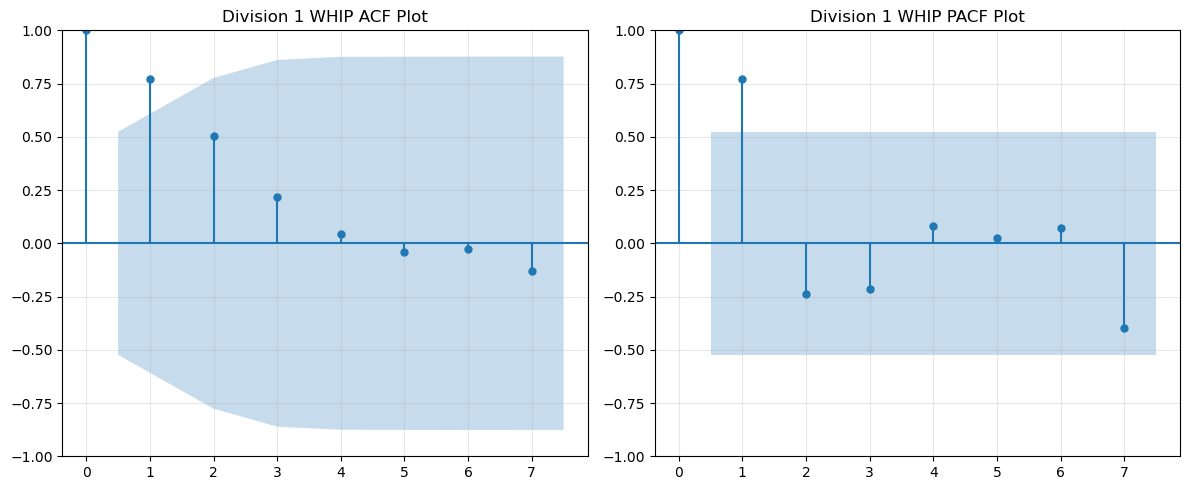

In [403]:
get_acf_pacf(metric='WHIP', metric_df=avg_metric_df, div=1)